<a href="https://colab.research.google.com/github/realclovisworld/Neural_Networks/blob/main/Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Design and implement an image Classification model to classfy a dataset of images using Deep Feed Foward NN. Record the accuracy correspending to the number of epchs. Use the MINST, CIFAR-10 datasets

In [2]:
# Load required packages

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras import Input
from keras.layers import Dense
import pandas as pd
import numpy as np
import sklearn
from sklearn.metrics import classification_report
import matplotlib
import matplotlib.pyplot as plt


In [3]:
#Load Digits Data

(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
#Print Shapes

print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (60000, 28, 28)
Shape of y_train: (60000,)
Shape of X_test: (10000, 28, 28)
Shape of y_test: (10000,)


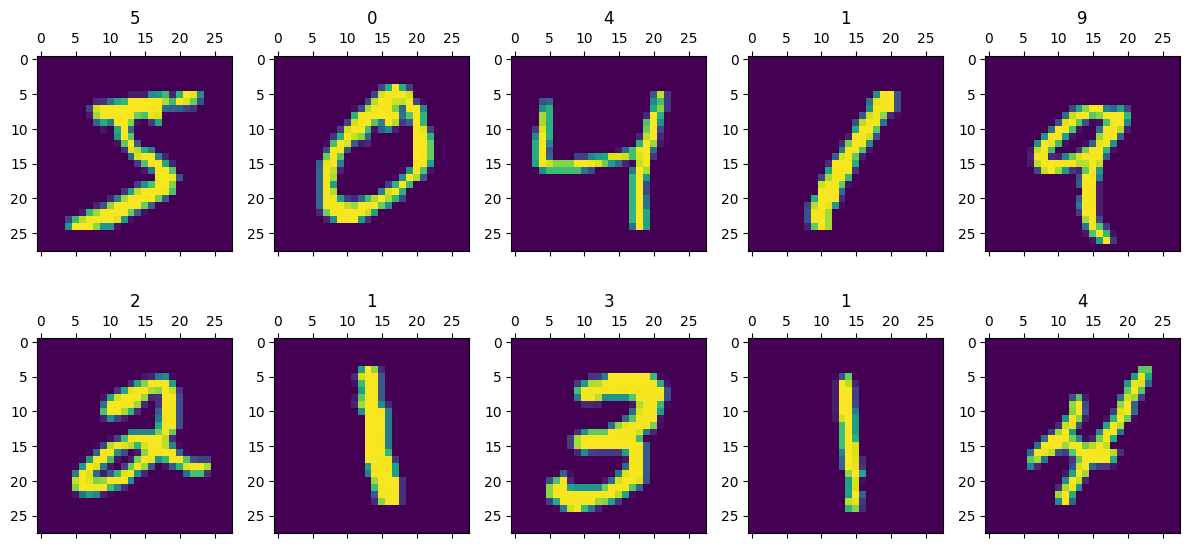

In [5]:
from jax._src.traceback_util import filter_traceback
#Display images of the first 10 digits in the trainig set and their true labels

fig,axs = plt.subplots(2,5, sharey=False, tight_layout=True, figsize=(12,6), facecolor='white')
n = 0
for i in range(0,2):
  for j in range(0,5):
    axs[i,j].matshow(X_train[n])
    axs[i,j].set(title=y_train[n])
    n += 1
plt.show()

In [6]:
#Reshape and normalise (divde by 255) input data

X_train = X_train.reshape(60000, 784).astype('float32') / 255
X_test = X_test.reshape(10000, 784).astype('float32') / 255


In [7]:
#Print New Shape

print("New Shape of X_train:",X_train.shape)
print("New Shape of X_test:",X_test.shape)

New Shape of X_train: (60000, 784)
New Shape of X_test: (10000, 784)


In [8]:
#Design the deep FF Neural Network Architecture

model = Sequential(name="DFF-Model") #Model
model.add(Input(shape=(784,), name="Input-Layer")) #input
model.add(Dense(128, activation='relu', name='Hidden-Layer-1')) #Hidden Layer 1
model.add(Dense(64, activation='relu', name='Hidden-Layer-2')) #Hidden Layer 2
model.add(Dense(32, activation='relu', name='Hidden-Layer-3')) #Hidden Layer 3
model.add(Dense(10, activation='softmax', name='Output-Layer')) #Output Layer
model.summary()

Model: "DFF-Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden-Layer-1 (Dense)          │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden-Layer-2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden-Layer-3 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output-Layer (Dense)            │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(optimizer='adam',
loss = 'SparseCategoricalCrossentropy',
metrics=['Accuracy'], run_eagerly=True)

In [10]:
#Train the model

model.fit(X_train, y_train, batch_size = 10, epochs=5)

Epoch 1/5
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 353s 58ms/step - Accuracy: 0.9325 - loss: 0.2252
Epoch 2/5
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 347s 58ms/step - Accuracy: 0.9683 - loss: 0.1039
Epoch 3/5
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 377s 63ms/step - Accuracy: 0.9760 - loss: 0.0772
Epoch 4/5
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 387s 64ms/step - Accuracy: 0.9812 - loss: 0.0613
Epoch 5/5
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 367s 61ms/step - Accuracy: 0.9841 - loss: 0.0518


In [11]:
#Prediction
pred_labels_tr = np.array(tf.math.argmax(model.predict(X_train), axis=1))

#Predict class labels on the test data
pred_labels_te = np.array(tf.math.argmax(model.predict(X_test), axis=1))

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [12]:
print('___________Evaluation on Training Data___________')
print(classification_report(y_train, pred_labels_tr))
print('___________Evaluation on Test Data___________')
print(classification_report(y_test, pred_labels_te))

___________Evaluation on Training Data___________
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      5923
           1       0.99      1.00      0.99      6742
           2       0.98      0.99      0.99      5958
           3       0.98      0.99      0.98      6131
           4       0.97      1.00      0.98      5842
           5       0.98      0.99      0.98      5421
           6       1.00      0.97      0.98      5918
           7       0.99      0.98      0.99      6265
           8       0.98      0.99      0.99      5851
           9       0.98      0.98      0.98      5949

    accuracy                           0.99     60000
   macro avg       0.99      0.99      0.99     60000
weighted avg       0.99      0.99      0.99     60000

___________Evaluation on Test Data___________
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       980
           1       0.99      0.99   

In [15]:
#Save the model

model.save('DFF-Model.keras')

In [17]:
#Load the model

from tensorflow.keras.models import load_model
model = load_model('DFF-Model.keras')

In [29]:
#load and preperocess unseen data

image_path = '/content/image5.webp'
image = keras.preprocessing.image.load_img(image_path, target_size=(28, 28), color_mode='grayscale')
image = keras.preprocessing.image.img_to_array(image)
image = image.reshape(1, 784).astype('float32') / 255

In [30]:
#Make prediction
prediction= model.predict(image)
predicted_class = np.argmax(prediction)
print("The predicted class is:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
The predicted class is: 8
